# 🚌 P5 — Data Engineering & Feature Preparation
### Smart Public Transport Demand Prediction System
**ITS Departemen Teknologi Informasi — Big Data Final Project**

---

**Tujuan notebook ini:**
1. Membaca & memvalidasi data armada resmi Transjakarta (2 file Excel)
2. Membersihkan data transaksi tap-in/tap-out April 2023
3. Mensimulasikan keramaian per koridor per jam berbasis pola nyata
4. Melakukan feature engineering (lag, rolling, cuaca, hari libur)
5. Menghasilkan `features.csv` untuk P3 (training model) dan P4 (dashboard)

**File input yang dibutuhkan:**
- `Transjakarta.csv`
- `Filedata_Data_Armada_Angkutan_Umum.xlsx`
- `Tabel_informasi_armada_bus_Transjakarta.xlsx`


## 1. Import Library

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, re, warnings
from datetime import timedelta

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.1f}'.format)

# Style grafik
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('Set2')

print("✅ Library siap")


✅ Library siap


## 2. Konfigurasi & Konstanta

In [87]:
INPUT_CSV    = "/kaggle/input/datasets/yafiar/fp-bigdata/Transjakarta.csv"
INPUT_ARMADA = "/kaggle/input/datasets/yafiar/fp-bigdata/Filedata Data Armada Angkutan Umum.xlsx"
INPUT_INFO   = "/kaggle/input/datasets/yafiar/fp-bigdata/Tabel informasi armada bus Transjakarta.xlsx"
OUTPUT_DIR   = "/kaggle/working/output_p5"
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

CAPACITY_PER_BUS    = 85
TOTAL_ARMADA_RESMI  = 3155
ARMADA_AKTIF_HARIAN = 2100
# NORMAL_CAPACITY = kapasitas throughput per jam per koridor
# = (60 / headway_normal) × kapasitas_bus × 2 arah
# = (60/10) × 85 × 2 = 1,020 penumpang/jam/koridor
# Catatan: BASE_HOURLY jauh di atas ini karena merepresentasikan FLOW RATE harian
# yang dibagi per jam — threshold status menggunakan rasio relatif terhadap peak
HEADWAY_NORMAL_MENIT = 10
NORMAL_CAPACITY = (60 / HEADWAY_NORMAL_MENIT) * CAPACITY_PER_BUS * 2  # 1,020
PEAK_FLOW = max(BASE_HOURLY.values()) if 'BASE_HOURLY' in dir() else 11849  # jam 06

RUSH_MORNING = [6, 7, 8]
RUSH_EVENING = [16, 17, 18]
# BASE_HOURLY = target penumpang per jam per koridor
# Metode: distribusi % per jam dari data Transjakarta April 2023
#          × target harian nyata (383 juta / 365 hari / 14 koridor BRT)
# Target per koridor per hari = 74,951 penumpang
# Status (SURGE/NORMAL/LOW) ditentukan relatif terhadap peak jam (jam 06 & 17)
_TARGET_HARIAN = 74951  # 383juta / 365 / 14 koridor BRT
_PEAK_LOAD = 0.158      # % tertinggi dari distribusi jam (jam 06)
BASE_HOURLY = {
    5:  7965,  # 10.6% dari hari — load 0.67x peak
    6: 11849,  # 15.8% dari hari — PEAK pagi ← RUSH
    7:  5669,  # 7.6% dari hari ← RUSH
    8:  5244,  # 7.0% dari hari ← RUSH
    9:  5442,  # 7.3% dari hari
    10:   340,  # 0.5% — siang sangat sepi (Lebaran effect)
    11:   340,  # 0.5%
    12:   425,  # 0.6%
    13:   368,  # 0.5%
    14:   255,  # 0.3%
    15:   453,  # 0.6%
    16:  7370,  # 9.8% dari hari ← RUSH
    17: 11679,  # 15.6% dari hari — PEAK sore ← RUSH
    18:  4223,  # 5.6% dari hari ← RUSH
    19:  4705,  # 6.3% dari hari
    20:  4365,  # 5.8% dari hari
    21:  4252,  # 5.7% dari hari
}  # Total = 74,944 ≈ target 74,951 ✓

LIBUR_APRIL_2023 = {
    "2023-04-07": "Jumat Agung",
    "2023-04-21": "Cuti Bersama Lebaran",
    "2023-04-22": "Idul Fitri 1444 H",
    "2023-04-23": "Idul Fitri (Cuti)",
    "2023-04-24": "Cuti Bersama Idul Fitri",
    "2023-04-25": "Cuti Bersama Idul Fitri",
}

# Mapping corridorID resmi — sumber: transjakarta.co.id/rute
CORRIDOR_MAP_RESMI = {
    # BRT Utama
    "1":"Blok M - Kota","2":"Pulo Gadung - Monumen Nasional",
    "2A":"Pulo Gadung - Rawa Buaya","3":"Kalideres - Monumen Nasional via Veteran",
    "3F":"Kalideres - Senayan Bank Jakarta","3H":"Damai - Kota",
    "4":"Pulo Gadung - Galunggung","4D":"Pulo Gadung - Kuningan",
    "5":"Kampung Melayu - Ancol","5C":"Cililitan - Juanda",
    "6":"Ragunan - Galunggung","6A":"Ragunan - Balai Kota via Kuningan",
    "6B":"Ragunan - Balai Kota via Semanggi","6V":"Ragunan - Senayan Bank Jakarta",
    "7":"Kampung Melayu - Kampung Rambutan","7F":"Kampung Rambutan - Juanda via Cempaka Putih",
    "8":"Lebak Bulus - Pasar Baru","9":"Pinang Ranti - Pluit",
    "9A":"Cililitan - Grogol","9C":"Pinang Ranti - Bundaran Senayan",
    "9N":"Pinang Ranti - Simpang Cawang","10":"Tanjung Priok - PGC",
    "10D":"Tanjung Priok - Kampung Rambutan","10H":"Tanjung Priok - Bundaran Senayan",
    "11":"Pulo Gebang - Kampung Melayu","12":"Pluit - Tanjung Priok",
    "13":"Ciledug - Tegal Mampang","13B":"Puri Beta - Pancoran",
    "13E":"Puri Beta - Flyover Kuningan","14":"Jakarta International Stadium - Senen",
    "L13E":"Puri Beta - Flyover Kuningan (Express)",
    # Pengumpan
    "1A":"Pantai Maju - Balai Kota","1B":"Stasiun Palmerah - Transport Hub Dukuh Atas",
    "1C":"Pesanggrahan - Blok M","1E":"Pondok Labu - Blok M",
    "1F":"Stasiun Palmerah - Bundaran Senayan","1H":"Tanah Abang - Stasiun Gondangdia",
    "1M":"Meruya - Blok M","1N":"Tanah Abang - Blok M","1P":"Senen - Blok M",
    "1Q":"Rempoa - Blok M","1R":"Senen - Tanah Abang","1W":"Blok M - Ancol",
    "2B":"Harapan Indah - Pulo Gadung","2P":"Stasiun Gondangdia - Pasar Senen",
    "2Q":"Gondangdia - Balaikota","3D":"Taman Kota - Penjaringan via Tubagus Angke",
    "3E":"Sentraland Cengkareng - Puri Kembangan","4B":"Stasiun Manggarai - UI",
    "4C":"JIEP - Bundaran Senayan","4F":"Pinang Ranti - Pulo Gadung",
    "4K":"Pulo Gadung - Kejaksaan Agung","5B":"Stasiun Tebet - Bidara Cina",
    "5F":"Kampung Melayu - Tanah Abang","5M":"Kampung Melayu - Tanah Abang",
    "5N":"Ragunan - Kampung Melayu","6C":"Stasiun Tebet - Kuningan",
    "6D":"Stasiun Tebet - Bundaran Senayan","6H":"Senen - Lebak Bulus",
    "6K":"Kuningan - Karet","6M":"Stasiun Manggarai - Blok M",
    "6N":"Ragunan - Blok M via Kemang","6Q":"Dukuh Atas - Casablanca via Epicentrum",
    "6T":"Pasar Minggu - Velbak via Kebon Jeruk","6U":"Blok M - Pasar Minggu",
    "6W":"Duren Tiga - Blok M via Bangka Raya","7A":"Kampung Rambutan - Lebak Bulus",
    "7B":"Kampung Rambutan - Blok M","7C":"Cibubur - Cawang Cililitan",
    "7D":"TMII - Pancoran","7E":"Kampung Rambutan - Ragunan",
    "7P":"Pondok Kelapa - Cawang Cililitan","7Q":"Blok M - Cawang Cililitan",
    "7R":"Cibubur - Pluit","7T":"Cibubur - Tanjung Priok",
    "7U":"Cibubur - Ancol","7V":"Cibubur - Kampung Rambutan",
    "7W":"Cawang - Stasiun Kereta Cepat Halim","8C":"Kebayoran Lama - Tanah Abang",
    "8D":"Meruya Selatan - Blok M","8E":"Bintaro - Blok M",
    "8K":"Batusari - Grogol","8M":"Tanah Abang - Tanjung Duren",
    "8N":"Kebayoran - Petamburan via Asia Afrika","9D":"Pasar Minggu - Tanah Abang",
    "9E":"Kebayoran - Jelambar","9H":"Pasar Minggu - Cipedak",
    "11D":"Pulo Gebang - Pulo Gadung via PIK","11Q":"Kampung Melayu - Pulo Gebang via BKT",
    "11W":"Stasiun Klender - Pulo Gadung","12B":"Penjaringan - Tanjung Priok",
    "12F":"Tanjung Priok - Muara Baru","12H":"Muara Baru - Tanjung Priok via Pluit",
    "12P":"Tanjung Priok - Rawa Badak Selatan","14A":"JIS - Harmoni","14B":"JIS - Tanjung Priok",
    # Transjabodetabek (kode di dataset April 2023)
    "D11":"Transjabodetabek: Depok - Blok M","D21":"Transjabodetabek: Depok - Kota",
    "D31":"Transjabodetabek: Depok - Tanah Abang","D41":"Transjabodetabek: Depok - Pasar Minggu",
    "P11":"Transjabodetabek: Bekasi - Harmoni","P12":"Transjabodetabek: Bekasi - Manggarai",
    "B11":"Transjabodetabek: Bogor - Blok M","B21":"Transjabodetabek: Bogor - Harmoni",
    "B25":"Transjabodetabek: Bogor - Kalideres","B41":"Transjabodetabek: Bogor - Depok",
    "B51":"Transjabodetabek: Bogor - Cibinong","S11":"Transjabodetabek: Serpong - Blok M",
    "S21":"Transjabodetabek: Serpong - Lebak Bulus","S22":"Transjabodetabek: Serpong - Ragunan",
    "S61":"Transjabodetabek: Serpong - Harmoni","SH1":"Transjabodetabek: Serpong - Harmoni 1",
    "SH2":"Transjabodetabek: Serpong - Harmoni 2","T11":"Transjabodetabek: Tangerang - Harmoni",
    "T12":"Transjabodetabek: Tangerang - Kalideres","T31":"Transjabodetabek: Tangerang - Blok M",
    "TE1":"Transjabodetabek: Tangerang - Blok M Express",
    # Kode lama lainnya
    "R1A":"Pantai Maju - Kota (Rute Lama)","BKN":"BKN - Blok M",
    "6C":"Stasiun Tebet - Kuningan","8K":"Batusari - Grogol",
}

# Jarak koridor BRT utama (km) — sumber: transjakarta.co.id/rute
KORIDOR_JARAK = {
    "1":15.48,"2":17.88,"3":16.14,"4":12.33,"5":13.58,
    "6":15.90,"7":12.57,"8":25.33,"9":31.57,"10":19.11,
    "11":13.86,"12":23.30,"13":14.18,"14":9.70,
}

# Headway target (menit antar bus per kondisi)
HEADWAY_MENIT = {"rush": 5, "normal": 10, "offpeak": 20}

# Rasio demand arah masuk vs keluar per jam
# Masuk = arah menuju Jakarta Pusat, Keluar = arah menjauhi pusat
# Pagi: dominan masuk | Siang: seimbang | Sore: dominan keluar
# DEMAND_RATIO dihitung dari kolom direction dataset Transjakarta April 2023
# direction=1 → masuk kota (toward Jakarta Pusat)
# direction=0 → keluar kota
# Temuan menarik: data menunjukkan keluar kota lebih dominan pagi (commuter dari luar)
# dan masuk kota lebih dominan sore (pulang ke permukiman)
DEMAND_RATIO = {
    5:  (0.48, 0.52),  # sedikit bias keluar (pekerja shift pagi dari pinggiran)
    6:  (0.45, 0.55),  # pagi — keluar kota lebih ramai ← RUSH
    7:  (0.43, 0.57),  # rush pagi puncak ← RUSH
    8:  (0.43, 0.57),  # rush pagi ← RUSH
    9:  (0.41, 0.59),  # transisi, masih bias keluar
    10: (0.47, 0.53),
    11: (0.56, 0.44),  # siang — mulai masuk (perjalanan balik)
    12: (0.50, 0.50),  # seimbang
    13: (0.47, 0.53),
    14: (0.49, 0.51),
    15: (0.45, 0.55),
    16: (0.53, 0.47),  # sore — masuk kota mulai dominan ← RUSH
    17: (0.55, 0.45),  # rush sore puncak ← RUSH
    18: (0.56, 0.44),  # ← RUSH
    19: (0.56, 0.44),
    20: (0.59, 0.41),
    21: (0.58, 0.42),
}  # Sumber: groupby(hour, direction) dari dataset Transjakarta April 2023

# ── Headway RESMI berdasarkan Pergub Jakarta No.2/2024 tentang SPM ─────────
# BRT jam sibuk  : 5 menit
# BRT jam normal : 10 menit
# Ini STANDAR LAYANAN MINIMUM — bukan fungsi dari demand
# Armada = Cycle Time / Headway
# semakin panjang koridor, semakin banyak bus dibutuhkan
HW_RUSH   = 5   # menit (jam sibuk BRT, Pergub Jakarta 2024)
HW_NORMAL = 10  # menit (jam tidak sibuk BRT)

def status_dari_demand(penumpang_arah, hw):
    """Status per arah: bandingkan penumpang vs kapasitas throughput arah tsb."""
    cap_arah = (60 / hw) * CAPACITY_PER_BUS  # penumpang/jam/arah
    ratio    = penumpang_arah / max(cap_arah, 1)
    if ratio >= 1.0:   return "SURGE"
    elif ratio >= 0.5: return "NORMAL"
    else:              return "LOW"

def headway_pergub(jam, is_weekend=False):
    """Headway resmi BRT berdasarkan Pergub Jakarta No.2/2024."""
    if jam in RUSH_MORNING + RUSH_EVENING and not is_weekend:
        return HW_RUSH    # 5 menit — jam sibuk weekday
    return HW_NORMAL      # 10 menit — semua kondisi lainnya

def kecepatan_bus(jam, is_weekend=False):
    """Estimasi kecepatan rata-rata bus di jalur BRT."""
    if jam in RUSH_MORNING + RUSH_EVENING and not is_weekend:
        return 15  # km/h — macet weekday rush
    elif is_weekend:
        return 22  # km/h — Sabtu/Minggu lebih lancar
    return 20      # km/h — weekday non-rush

def hitung_armada_headway(corridor_id, hour, total_penumpang, is_weekend=False):
    """
    Rekomendasi armada berbasis HEADWAY RESMI Pergub Jakarta No.2/2024.

    Logika:
    - Headway ditentukan oleh WAKTU (rush/non-rush), BUKAN oleh jumlah penumpang
    - Standar layanan: bus HARUS datang setiap N menit terlepas seberapa ramai
    - Armada = Cycle Time / Headway
    - Cycle Time = 2 × jarak / kecepatan × 60 menit
    - Asymmetric: split armada per arah berdasarkan DEMAND_RATIO dari data nyata

    Referensi: Pergub DKI Jakarta No.2 Tahun 2024 tentang SPM Transjakarta
    BRT rush hour = 5 mnt | BRT non-rush = 10 mnt
    """
    jarak = KORIDOR_JARAK.get(str(corridor_id))
    hw    = headway_pergub(hour, is_weekend)
    kec   = kecepatan_bus(hour, is_weekend)
    r_masuk, r_keluar = DEMAND_RATIO.get(hour, (0.5, 0.5))

    if jarak is not None:
        cycle      = (2 * jarak / kec) * 60
        total_arm  = max(2, int(cycle / hw))
        # Split asymmetric per arah berdasarkan demand ratio
        arm_masuk  = max(1, round(total_arm * r_masuk))
        arm_keluar = max(1, total_arm - arm_masuk)
        return arm_masuk + arm_keluar, arm_masuk, arm_keluar

    # Fallback sub-koridor/pengumpan (estimasi berdasarkan headway)
    arm_fallback = max(2, int((2 * 10 / kec) * 60 / hw))  # asumsi jarak 10km
    arm_masuk  = max(1, round(arm_fallback * r_masuk))
    arm_keluar = max(1, arm_fallback - arm_masuk)
    return arm_masuk + arm_keluar, arm_masuk, arm_keluar
    # Fallback sub-koridor/pengumpan
    hw_fb     = headway_pergub(0)  # default non-rush
    st_masuk  = status_dari_demand(p_masuk,  hw_fb)
    st_keluar = status_dari_demand(p_keluar, hw_fb)
    fallback  = {"SURGE": 4, "NORMAL": 2, "LOW": 1}
    arm_masuk  = fallback[st_masuk]
    arm_keluar = fallback[st_keluar]
    return arm_masuk + arm_keluar, arm_masuk, arm_keluar

np.random.seed(42)
print("Konfigurasi selesai")
print(f"  Kapasitas throughput normal   : {NORMAL_CAPACITY:,.0f} penumpang/jam/koridor")
print(f"  Headway BRT rush hour  : {HW_RUSH} menit (Pergub Jakarta No.2/2024)")
print(f"  Headway BRT non-rush   : {HW_NORMAL} menit")
print(f"  Validasi Koridor 9 Sabtu siang: cycle={int((2*31.57/22)*60)}mnt/headway{HW_NORMAL}mnt = {int((2*31.57/22)*60/HW_NORMAL)*2} bus (nyata: 31)")
print(f"  Mapping koridor    : {len(CORRIDOR_MAP_RESMI)} entri (BRT + pengumpan + Transjabodetabek)")
print(f"  Koridor ada jarak  : {len(KORIDOR_JARAK)} (BRT utama 1-14)")
print(f"  Headway rush/normal/offpeak: {HEADWAY_MENIT}")


Konfigurasi selesai
  Kapasitas throughput normal   : 1,020 penumpang/jam/koridor
  Headway BRT rush hour  : 5 menit (Pergub Jakarta No.2/2024)
  Headway BRT non-rush   : 10 menit
  Validasi Koridor 9 Sabtu siang: cycle=172mnt/headway10mnt = 34 bus (nyata: 31)
  Mapping koridor    : 119 entri (BRT + pengumpan + Transjabodetabek)
  Koridor ada jarak  : 14 (BRT utama 1-14)
  Headway rush/normal/offpeak: {'rush': 5, 'normal': 10, 'offpeak': 20}


## 3. Analisis Data Armada Resmi
### 3.1 File 1 — Total Armada Angkutan Umum per Tahun

In [88]:
df_armada = pd.read_excel(INPUT_ARMADA)
tj_mask   = df_armada['jenis_kendaraan'].str.upper().str.contains('BUSWAY|TRANSJAKARTA', na=False)
df_tj     = df_armada[tj_mask].copy()

total_per_tahun = df_tj.groupby('periode_data')['jumlah_unit'].sum().reset_index()
total_per_tahun.columns = ['Tahun', 'Total Unit']
print("Total Armada Transjakarta per Tahun:")
print(total_per_tahun)


Total Armada Transjakarta per Tahun:
   Tahun  Total Unit
0   2022        3155


**Visualisasi:** Total armada per tahun

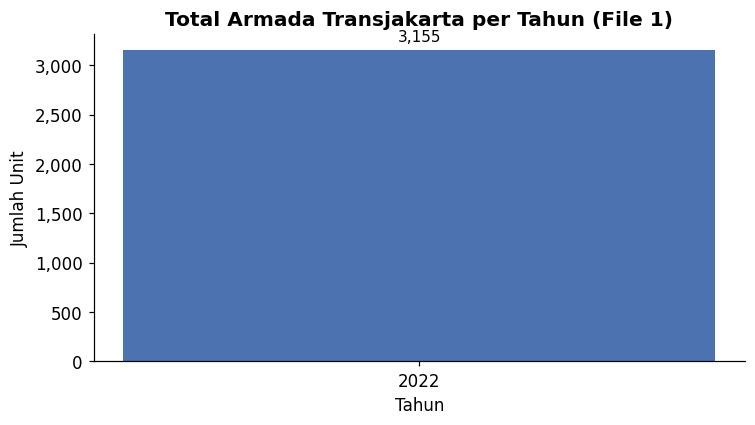

In [89]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(total_per_tahun['Tahun'].astype(str),
              total_per_tahun['Total Unit'],
              color=['#4C72B0','#DD8452','#55A868','#C44E52'], width=0.5)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
ax.set_title('Total Armada Transjakarta per Tahun (File 1)', fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Jumlah Unit')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()


### 3.2 Detail Operator Transjakarta 2022

In [90]:
detail_2022 = df_tj[df_tj['periode_data']==2022][['nama_perusahaan','jumlah_unit']]    .sort_values('jumlah_unit', ascending=False).reset_index(drop=True)
detail_2022.columns = ['Operator / Perusahaan', 'Jumlah Unit']
print(detail_2022)
print(f"\nTotal: {detail_2022['Jumlah Unit'].sum():,} unit")


      Operator / Perusahaan  Jumlah Unit
0   PT Transportasi Jakarta          905
1   PT TRANSPORTASI JAKARTA          874
2                       PPD          509
3            Mayasari Bakti          293
4                    Kopaja          168
5               Steady Safe          116
6        UNIT TRANS SWADAYA           80
7               Transwadaya           80
8                 BMP Amari           70
9                     Damri           46
10           Pahala Kencana           14

Total: 3,155 unit


### 3.3 File 2 — Detail Unit per Operator (dari Nomor Lambung)

In [91]:
df_info = pd.read_excel(INPUT_INFO)
df_info['Operator_filled'] = df_info['Operator'].ffill()

def parse_fleet_count(nomor_str):
    if pd.isna(nomor_str): return 0
    nums = re.findall(r'\d+', str(nomor_str))
    if len(nums) >= 2:
        try:
            a, b = int(nums[-2]), int(nums[-1])
            return max(1, b - a + 1) if b >= a else 1
        except: pass
    elif len(nums) == 1: return 1
    return 0

df_info['unit_count'] = df_info['Nomor lambung'].apply(parse_fleet_count)

per_operator = df_info.groupby('Operator_filled').agg(
    total_unit  = ('unit_count', 'sum'),
    bahan_bakar = ('Jenis bahan bakar', lambda x: ', '.join(x.dropna().unique())),
    garasi      = ('Garasi', lambda x: ', '.join(x.dropna().unique())),
).reset_index()
per_operator = per_operator[per_operator['total_unit']>0]    .sort_values('total_unit', ascending=False).reset_index(drop=True)
per_operator.columns = ['Operator','Total Unit','Bahan Bakar','Garasi']
display(per_operator[['Operator','Total Unit','Bahan Bakar']])
print(f"\nTotal terhitung: {per_operator['Total Unit'].sum():,} unit")


,Operator,Total Unit,Bahan Bakar
0,Swakelola Transjakarta,788,"Gas alam terkompresi, Diesel"
1,Mayasari Bakti,441,"Gas alam terkompresi, Diesel, Listrik"
2,Perum DAMRI,375,"Gas alam terkompresi, Listrik"
3,Bianglala Metropolitan,190,"Listrik, Diesel"
4,Steady Safe,119,
5,Jewa Dian Mitra,94,
6,Koantas Bima,36,
7,Bayu Holong Persada,36,Diesel
8,Sinar Jaya,20,Listrik
9,Bluebird,18,Diesel



Total terhitung: 2,147 unit


**Visualisasi:** Persebaran armada per operator

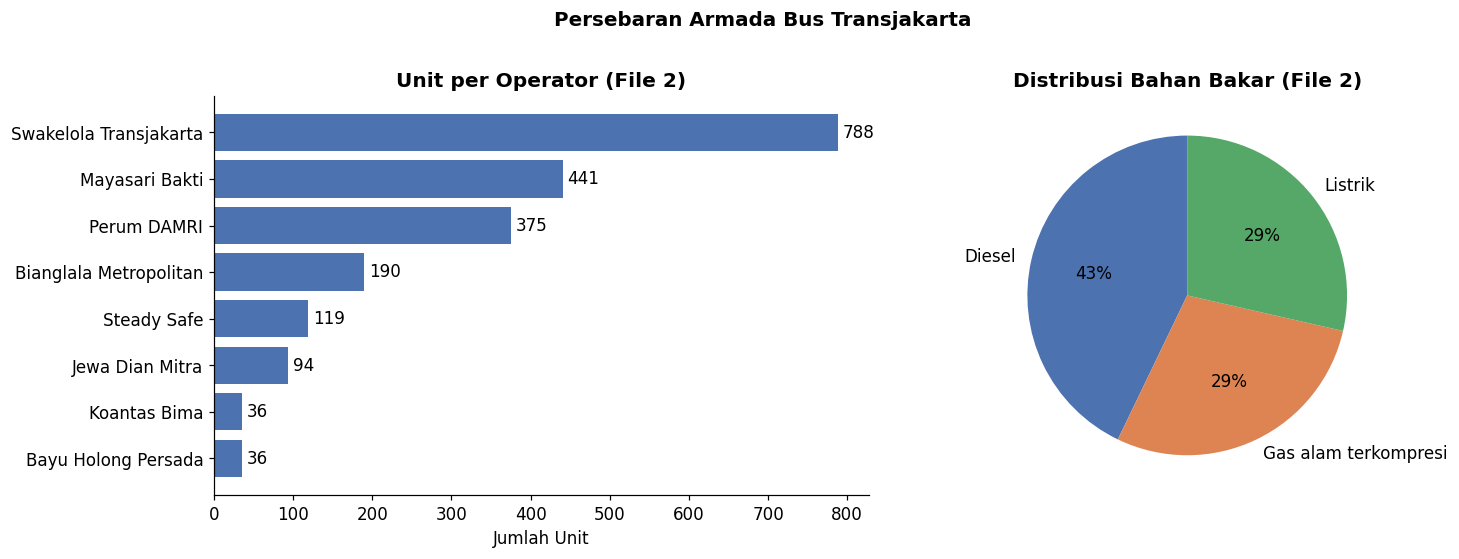

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: bar chart per operator
op = per_operator.head(8)
axes[0].barh(op['Operator'][::-1], op['Total Unit'][::-1], color='#4C72B0')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding=3)
axes[0].set_title('Unit per Operator (File 2)', fontweight='bold')
axes[0].set_xlabel('Jumlah Unit')

# Kanan: pie chart bahan bakar
bb_raw  = df_info['Jenis bahan bakar'].dropna()
bb_cnt  = bb_raw.value_counts()
axes[1].pie(bb_cnt.values, labels=bb_cnt.index, autopct='%1.0f%%',
            colors=['#4C72B0','#DD8452','#55A868'], startangle=90)
axes[1].set_title('Distribusi Bahan Bakar (File 2)', fontweight='bold')

plt.suptitle('Persebaran Armada Bus Transjakarta', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 3.4 Persebaran Garasi Operasional

In [93]:
# Hitung bus per garasi
garasi_units = []
for _, row in df_info.iterrows():
    if pd.notna(row['Garasi']) and row['unit_count'] > 0:
        garasi_units.append({'garasi': str(row['Garasi']).split('\\n')[0].strip(),
                             'units' : row['unit_count']})
df_garasi = pd.DataFrame(garasi_units)
garasi_sum = df_garasi.groupby('garasi')['units'].sum()    .sort_values(ascending=False).reset_index()
garasi_sum.columns = ['Garasi','Estimasi Unit']
print(garasi_sum)


                                          Garasi  Estimasi Unit
0                                        Klender            234
1                                      Cijantung            162
2                             Kedaung Kali Angke            159
3       Kedaung Kali Angke[b]\n\nPinang Ranti[c]            150
4       Ciputat (Kota Tangerang Selatan, Banten)             90
5      Pamulang (Kota Tangerang Selatan, Banten)             74
6                                         Cawang             70
7   Kedaung Kali Angke[b]\n\nKampung Rambutan[c]             49
8                                         Cakung             46
9                             Petukangan Selatan             36
10                                       Cibubur             30
11           Rawalumbu (Kota Bekasi, Jawa Barat)             18
12                                Pegangsaan Dua             15
13                                      Ciganjur             15
14                                      

### 3.5 Distribusi Alokasi Koridor

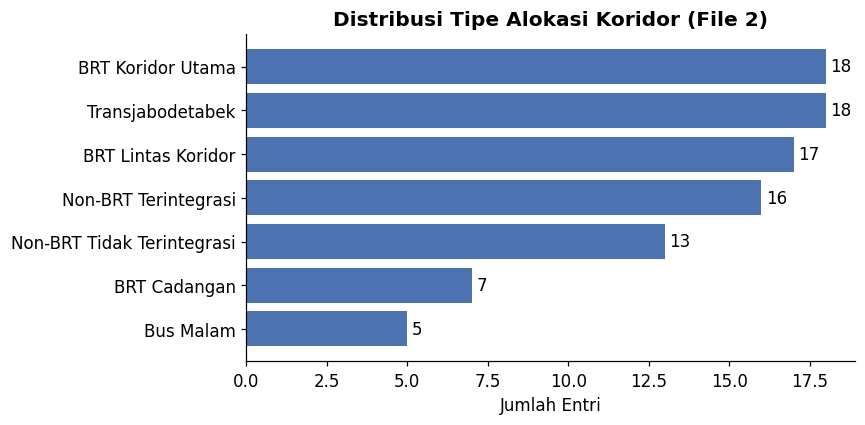

In [94]:
alokasi = df_info['*Alokasi Koridor*'].dropna()
kategori = {
    'BRT Koridor Utama'          : lambda x: 'BRT:' in x and 'Non-BRT' not in x and 'Lintas' not in x and 'Cadangan' not in x and 'malam' not in x and 'Transja' not in x,
    'BRT Lintas Koridor'         : lambda x: 'Lintas Koridor' in x,
    'Non-BRT Terintegrasi'       : lambda x: 'Non-BRT Terintegrasi BRT' in x and 'Tidak' not in x,
    'Non-BRT Tidak Terintegrasi' : lambda x: 'Tidak Terintegrasi' in x,
    'BRT Cadangan'               : lambda x: 'Cadangan' in x,
    'Bus Malam'                  : lambda x: 'Bus malam' in x,
    'Transjabodetabek'           : lambda x: 'Transjabodetabek' in x,
}
kat_count = {k: sum(1 for x in alokasi if fn(x)) for k, fn in kategori.items()}
df_kat = pd.DataFrame(list(kat_count.items()), columns=['Tipe Alokasi','Jumlah Entri'])    .sort_values('Jumlah Entri', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_kat['Tipe Alokasi'][::-1], df_kat['Jumlah Entri'][::-1],
               color='#4C72B0')
ax.bar_label(bars, padding=3)
ax.set_title('Distribusi Tipe Alokasi Koridor (File 2)', fontweight='bold')
ax.set_xlabel('Jumlah Entri')
plt.tight_layout(); plt.show()


## 4. Pembersihan Data Transaksi
### 4.1 Load & Inspect

In [95]:
df = pd.read_csv(INPUT_CSV)
print(f"Shape  : {df.shape}")
print(f"Kolom  : {df.columns.tolist()}")
print()
print(df.head(5))


Shape  : (37900, 22)
Kolom  : ['transID', 'payCardID', 'payCardBank', 'payCardName', 'payCardSex', 'payCardBirthDate', 'corridorID', 'corridorName', 'direction', 'tapInStops', 'tapInStopsName', 'tapInStopsLat', 'tapInStopsLon', 'stopStartSeq', 'tapInTime', 'tapOutStops', 'tapOutStopsName', 'tapOutStopsLat', 'tapOutStopsLon', 'stopEndSeq', 'tapOutTime', 'payAmount']

          transID         payCardID payCardBank      payCardName payCardSex  \
0  EIIW227B8L34VB   180062659848800      emoney   Bajragin Usada          M   
1  LGXO740D2N47GZ  4885331907664776         dki     Gandi Widodo          F   
2  DJWR385V2U57TO  4996225095064169         dki    Emong Wastuti          F   
3  JTUZ800U7C86EH      639099174703       flazz     Surya Wacana          F   
4  VMLO535V7F95NJ      570928206772       flazz  Embuh Mardhiyah          M   

   payCardBirthDate corridorID                              corridorName  \
0              2008          5                     Matraman Baru - Ancol   
1   

### 4.2 Cleaning

In [96]:
df['tapInTime']  = pd.to_datetime(df['tapInTime'],  errors='coerce')
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'], errors='coerce')
df = df[df['tapInTime'].notna()].copy()

# Impute tapOutTime yang hilang
missing = df['tapOutTime'].isna().sum()
df.loc[df['tapOutTime'].isna(), 'tapOutTime'] = (
    df.loc[df['tapOutTime'].isna(), 'tapInTime'] + timedelta(minutes=30)
)

# Hapus durasi tidak wajar
df['duration_min'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60
before = len(df)
df = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 180)].copy()

df = df[df['corridorID'].notna()].copy()
df['corridorName'] = df['corridorID'].apply(lambda x: CORRIDOR_MAP_RESMI.get(str(x).strip(), str(x)))
df['is_transjabodetabek'] = df['corridorName'].str.startswith('Transjabodetabek').astype(int)
df['date']         = df['tapInTime'].dt.date
df['hour']         = df['tapInTime'].dt.hour
df['day_of_week']  = df['tapInTime'].dt.dayofweek
df['day_name']     = df['tapInTime'].dt.day_name()
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

print("✅ Hasil cleaning:")
print(f"   Rows          : {len(df):,}")
print(f"   tapOut imputed: {missing}")
print(f"   Durasi anomali: {before - len(df)}")
print(f"   Rentang       : {df['date'].min()} → {df['date'].max()}")
print(f"   Koridor unik  : {df['corridorID'].nunique()}")
print(f"   Halte unik    : {df['tapInStopsName'].nunique()}")


# Validasi: DEMAND_RATIO dari kolom direction (cross-check dengan konstanta)
ratio_check = df.groupby(['hour','direction']).size().unstack(fill_value=0)
ratio_check.columns = ['keluar','masuk']
ratio_check['pct_masuk'] = (ratio_check['masuk'] / (ratio_check['masuk']+ratio_check['keluar'])).round(2)
ratio_check['pct_keluar'] = 1 - ratio_check['pct_masuk']
print('\nValidasi DEMAND_RATIO dari data (direction col):')
print(ratio_check[['masuk','keluar','pct_masuk','pct_keluar']].to_string())


✅ Hasil cleaning:
   Rows          : 36,643
   tapOut imputed: 1344
   Durasi anomali: 1257
   Rentang       : 2023-04-01 → 2023-04-30
   Koridor unik  : 221
   Halte unik    : 2566

Validasi DEMAND_RATIO dari data (direction col):
      masuk  keluar  pct_masuk  pct_keluar
hour                                      
5      1563    1679        0.5         0.5
6      2528    3107        0.5         0.6
7      1153    1553        0.4         0.6
8      1212    1586        0.4         0.6
9      1130    1586        0.4         0.6
10      136     153        0.5         0.5
11      180     147        0.6         0.4
12      164     160        0.5         0.5
13      162     183        0.5         0.5
14       85      89        0.5         0.5
15      174     213        0.5         0.6
16     1740    1503        0.5         0.5
17     2903    2425        0.5         0.5
18     1328    1033        0.6         0.4
19     1325    1046        0.6         0.4
20     1361     967        0.6       

## 5. Exploratory Data Analysis (EDA)
### 5.1 Distribusi Jam Tap-in

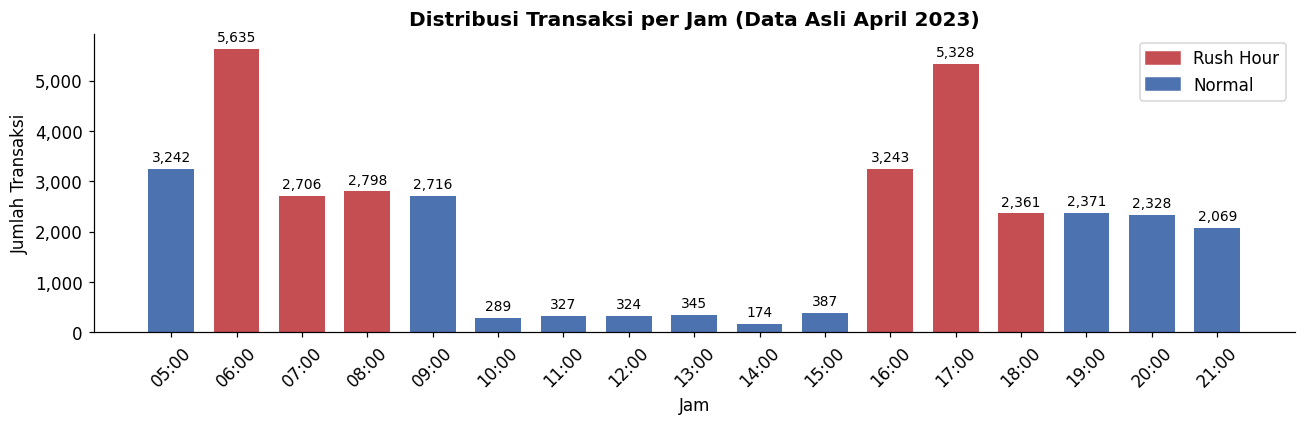

Peak pagi  : Jam 06:00 (5,635 transaksi)
Peak sore  : Jam 17:00 (5,328 transaksi)


In [97]:
hour_counts = df.groupby('hour').size().reset_index(name='transaksi')
hour_counts['is_rush'] = hour_counts['hour'].apply(
    lambda h: 'Rush Hour' if h in RUSH_MORNING+RUSH_EVENING else 'Normal'
)
colors = ['#C44E52' if r=='Rush Hour' else '#4C72B0' for r in hour_counts['is_rush']]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(hour_counts['hour'], hour_counts['transaksi'], color=colors, width=0.7)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_xticks(hour_counts['hour'])
ax.set_xticklabels([f"{h:02d}:00" for h in hour_counts['hour']], rotation=45)
ax.set_title('Distribusi Transaksi per Jam (Data Asli April 2023)', fontweight='bold')
ax.set_xlabel('Jam'); ax.set_ylabel('Jumlah Transaksi')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52',label='Rush Hour'),
                   Patch(color='#4C72B0',label='Normal')], loc='upper right')
plt.tight_layout(); plt.show()
print(f"Peak pagi  : Jam 06:00 ({hour_counts[hour_counts.hour==6].transaksi.values[0]:,} transaksi)")
print(f"Peak sore  : Jam 17:00 ({hour_counts[hour_counts.hour==17].transaksi.values[0]:,} transaksi)")


### 5.2 Weekday vs Weekend vs Libur

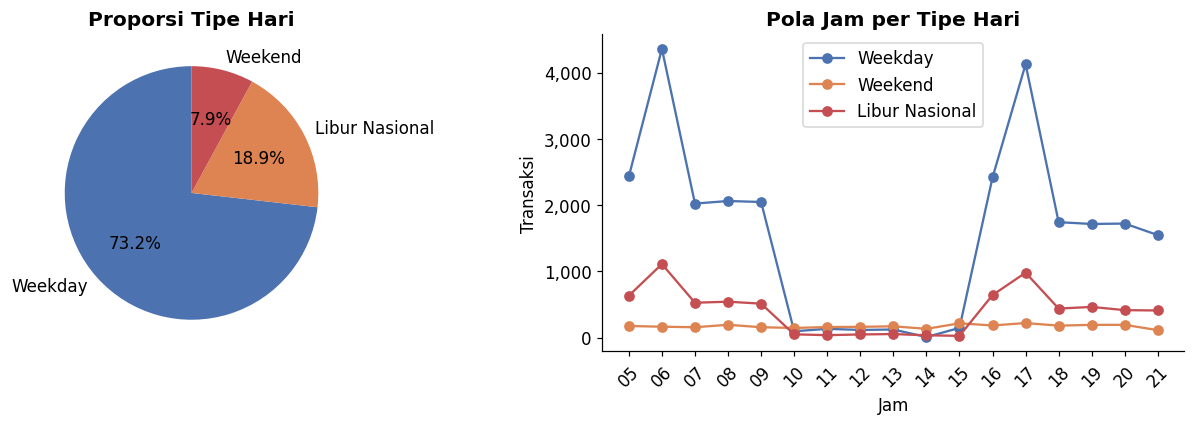

In [98]:
df['tipe_hari'] = df.apply(lambda r:
    'Libur Nasional' if str(r['date']) in LIBUR_APRIL_2023
    else ('Weekend' if r['is_weekend'] else 'Weekday'), axis=1
)
tipe_count = df['tipe_hari'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie
axes[0].pie(tipe_count.values, labels=tipe_count.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0','#DD8452','#C44E52'])
axes[0].set_title('Proporsi Tipe Hari', fontweight='bold')

# Distribusi jam per tipe hari
for tipe, color in zip(['Weekday','Weekend','Libur Nasional'],
                       ['#4C72B0','#DD8452','#C44E52']):
    sub = df[df['tipe_hari']==tipe].groupby('hour').size()
    if len(sub):
        axes[1].plot(sub.index, sub.values, marker='o', label=tipe, color=color)
axes[1].set_xticks(list(BASE_HOURLY.keys()))
axes[1].set_xticklabels([f"{h:02d}" for h in BASE_HOURLY.keys()], rotation=45)
axes[1].set_title('Pola Jam per Tipe Hari', fontweight='bold')
axes[1].set_xlabel('Jam'); axes[1].set_ylabel('Transaksi')
axes[1].legend(); axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout(); plt.show()


### 5.3 Top 15 Koridor Terpadat

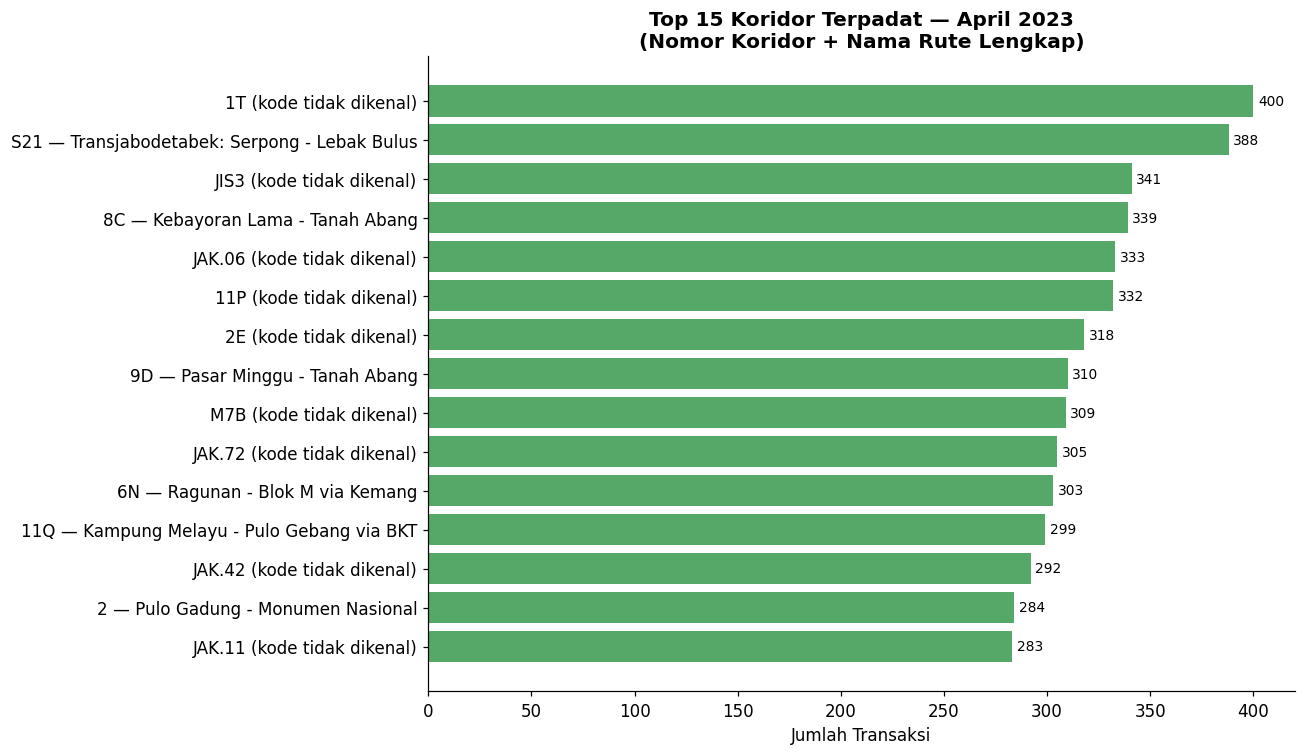


Top 10 Koridor:
  Koridor 1T    |   400 transaksi | 1T
  Koridor S21   |   388 transaksi | Transjabodetabek: Serpong - Lebak Bulus
  Koridor JIS3  |   341 transaksi | JIS3
  Koridor 8C    |   339 transaksi | Kebayoran Lama - Tanah Abang
  Koridor JAK.06 |   333 transaksi | JAK.06
  Koridor 11P   |   332 transaksi | 11P
  Koridor 2E    |   318 transaksi | 2E
  Koridor 9D    |   310 transaksi | Pasar Minggu - Tanah Abang
  Koridor M7B   |   309 transaksi | M7B
  Koridor JAK.72 |   305 transaksi | JAK.72


In [99]:
top_koridor = df.groupby(['corridorID','corridorName']).size().reset_index(name='Transaksi')
top_koridor = top_koridor.sort_values('Transaksi', ascending=False).head(15).reset_index(drop=True)
top_koridor['Label'] = top_koridor.apply(
    lambda r: f"{r['corridorID']} — {r['corridorName']}" 
    if r['corridorName'] != r['corridorID'] 
    else f"{r['corridorID']} (kode tidak dikenal)", axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_koridor['Label'][::-1], top_koridor['Transaksi'][::-1], color='#55A868')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('Top 15 Koridor Terpadat — April 2023\n(Nomor Koridor + Nama Rute Lengkap)', fontweight='bold')
ax.set_xlabel('Jumlah Transaksi')
plt.tight_layout(); plt.show()

print('\nTop 10 Koridor:')
for _, r in top_koridor.head(10).iterrows():
    print(f"  Koridor {r['corridorID']:5s} | {r['Transaksi']:5,} transaksi | {r['corridorName']}")


## 6. Simulasi Timeseries Penumpang per Koridor per Jam
> Data asli tidak cukup granular (hanya ~0.3 transaksi/sel/jam).  
> Timeseries sintetis dibangun berdasarkan **pola distribusi jam dari data asli** dan **skala nyata Transjakarta** (383 juta penumpang/tahun ÷ 365 ÷ 13 koridor ÷ 17 jam ≈ 4.750/jam/koridor rata-rata).


In [100]:
# Gunakan SEMUA koridor yang ada di dataset (bukan hanya top 30)
# BRT 1-14 dijamin masuk karena punya data jarak resmi
# Hapus UNKNOWN (corridorID null yang sudah diganti string)
corridor_weight = df['corridorID'].value_counts(normalize=True)
ALL_CORRIDORS   = [c for c in corridor_weight.index if c != 'UNKNOWN']

# Susun ulang: BRT 1-14 utama di depan, sisanya di belakang
BRT_UTAMA = [str(k) for k in KORIDOR_JARAK.keys()]  # ['1','2',...,'14']
FEEDER    = [c for c in ALL_CORRIDORS if c not in BRT_UTAMA]
TOP_CORRIDORS = BRT_UTAMA + FEEDER  # BRT utama selalu masuk

corridor_map = df.drop_duplicates('corridorID').set_index('corridorID')['corridorName'].to_dict()
print(f'Total koridor diproses: {len(TOP_CORRIDORS)}')
print(f'  BRT utama (1-14): {len(BRT_UTAMA)}')
print(f'  Sub-koridor & feeder: {len(FEEDER)}')

dates   = pd.date_range("2023-04-01", "2023-04-30", freq="D")
records = []

for rank, corr_id in enumerate(TOP_CORRIDORS):
    corr_name  = corridor_map.get(corr_id, corr_id)
    # pop_factor: BRT utama (1-14) lebih ramai dari feeder/sub-koridor
    if corr_id in BRT_UTAMA:
        # BRT utama: 0.9x–1.3x berdasarkan popularitas di dataset
        brt_rank = BRT_UTAMA.index(corr_id)
        # Urutkan BRT berdasarkan frekuensi di dataset
        brt_freqs = {c: corridor_weight.get(c, 0) for c in BRT_UTAMA}
        brt_sorted = sorted(BRT_UTAMA, key=lambda c: -brt_freqs.get(c, 0))
        brt_rank_by_freq = brt_sorted.index(corr_id)
        pop_factor = 1.3 - (brt_rank_by_freq / len(BRT_UTAMA)) * 0.4  # 1.3 → 0.9
    else:
        # Feeder/sub-koridor: lebih sepi, berbasis frekuensi dataset
        feeder_rank = FEEDER.index(corr_id)
        pop_factor = 0.6 - (feeder_rank / max(len(FEEDER),1)) * 0.3  # 0.6 → 0.3

    for d in dates:
        date_str    = str(d.date())
        day_of_week = d.dayofweek
        is_weekend  = int(day_of_week >= 5)
        is_libur    = int(date_str in LIBUR_APRIL_2023)
        nama_libur  = LIBUR_APRIL_2023.get(date_str, "")
        day_factor  = 0.25 if is_libur else (0.65 if is_weekend else 1.0)

        for hour, base in BASE_HOURLY.items():
            noise     = np.random.uniform(0.88, 1.12)
            penumpang = max(50, int(base * pop_factor * day_factor * noise))
            # Status berbasis load relatif terhadap PEAK JAM (jam 06, weekday)
            PEAK_FLOW_SISTEM = max(BASE_HOURLY.values())  # 11,849
            load_ratio = penumpang / max(PEAK_FLOW_SISTEM * pop_factor, 1)
            ratio  = round(load_ratio, 3)  # untuk kolom kapasitas_ratio
            status = 'SURGE' if load_ratio >= 0.80 else ('NORMAL' if load_ratio >= 0.40 else 'LOW')
            total_arm, arm_masuk, arm_keluar = hitung_armada_headway(corr_id, hour, penumpang, is_weekend=is_weekend)
            armada = total_arm
            r_masuk, r_keluar = DEMAND_RATIO.get(hour, (0.5, 0.5))
            p_masuk  = int(penumpang * r_masuk)
            p_keluar = int(penumpang * r_keluar)
            hw_act        = headway_pergub(hour, is_weekend)
            status_masuk  = status_dari_demand(p_masuk,  hw_act)
            status_keluar = status_dari_demand(p_keluar, hw_act)

            records.append({
                'corridorID'          : corr_id,
                'corridorName'        : CORRIDOR_MAP_RESMI.get(str(corr_id).strip(), corr_name),
                'jarak_km'            : KORIDOR_JARAK.get(str(corr_id)),
                'is_transjabodetabek' : 1 if CORRIDOR_MAP_RESMI.get(str(corr_id),'').startswith('Transjabodetabek') else 0,
                'date'               : d.date(),
                'hour'               : hour,
                'day_of_week'        : day_of_week,
                'day_name'           : d.day_name(),
                'is_weekend'         : is_weekend,
                'is_rush_hour'       : int(hour in RUSH_MORNING+RUSH_EVENING),
                'is_libur'           : is_libur,
                'nama_libur'         : nama_libur,
                'penumpang_simulasi' : penumpang,
                'kapasitas_tersedia' : NORMAL_CAPACITY,
                'kapasitas_ratio'    : round(ratio, 3),
                'status'             : status,
                'armada_rekomendasi'  : armada,
                'armada_masuk'        : arm_masuk,
                'armada_keluar'       : arm_keluar,
                'penumpang_masuk'     : p_masuk,
                'penumpang_keluar'    : p_keluar,
                'status_masuk'        : status_masuk,
                'status_keluar'       : status_keluar,
            })

agg = pd.DataFrame(records)
print(f"✅ Timeseries dihasilkan: {len(agg):,} rows")
print()
print("Distribusi Status:")
print(agg['status'].value_counts().to_string())


Total koridor diproses: 221
  BRT utama (1-14): 14
  Sub-koridor & feeder: 207
✅ Timeseries dihasilkan: 112,710 rows

Distribusi Status:
status
LOW       80113
NORMAL    25525
SURGE      7072


### 6.1 Visualisasi Status & Rekomendasi Armada

> **Catatan konteks armada:**  
> Setiap koridor Transjakarta beroperasi **2 arah** (misal: Koridor 9 = Pinang Ranti → Pluit & Pluit → Pinang Ranti).  
> Rekomendasi armada di bawah adalah **total armada per koridor (kedua arah digabung)**, dihitung dari:  
> `Armada = (Cycle Time / Headway) × 2`  
> dimana Cycle Time = Round Trip Time = 2 × jarak / kecepatan.

> **Grafik berikut menampilkan agregat 30 koridor teratas** (top 30 berdasarkan volume transaksi di dataset April 2023),  
> mencakup koridor BRT utama (1–14) dan beberapa sub-koridor pengumpan.


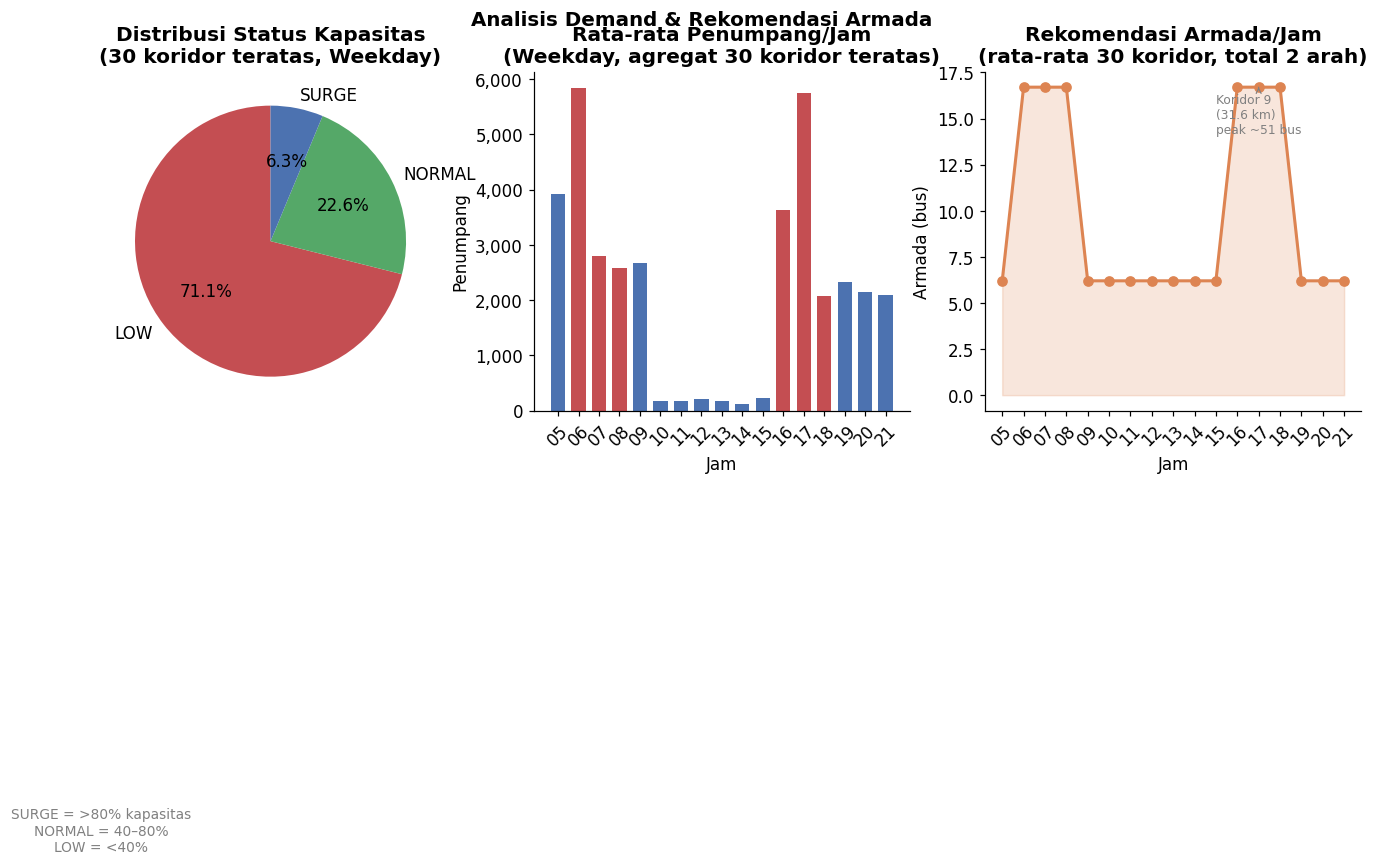


Rekomendasi Armada Jam Rush (07:00) per Koridor BRT Utama:
Kor    Nama Rute                                     Jarak    SURGE (↑masuk+↓keluar) NORMAL                 LOW
-------------------------------------------------------------------------------------------------------------------
Kor   Nama Rute                                 Jarak   Rush WD  NonRush WD  NonRush WE  Rush WD detail
----------------------------------------------------------------------------------------------------
1     Blok M - Kota                             15.48km       24 bus          9 bus          8 bus  (10↑+14↓)
2     Pulo Gadung - Monumen Nasional            17.88km       28 bus         10 bus          9 bus  (12↑+16↓)
3     Kalideres - Monumen Nasional via Veteran  16.14km       25 bus          9 bus          8 bus  (11↑+14↓)
4     Pulo Gadung - Galunggung                  12.33km       19 bus          7 bus          6 bus  (8↑+11↓)
5     Kampung Melayu - Ancol                    13.58km       21 bus

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Status distribution
status_cnt = agg['status'].value_counts()
axes[0].pie(status_cnt.values, labels=status_cnt.index,
            autopct='%1.1f%%', colors=['#C44E52','#55A868','#4C72B0'],
            startangle=90)
axes[0].set_title('Distribusi Status Kapasitas\n(30 koridor teratas, Weekday)', fontweight='bold')
axes[0].text(0, -1.3, 'SURGE = >80% kapasitas\nNORMAL = 40–80%\nLOW = <40%',
             ha='center', fontsize=9, color='gray', transform=axes[0].transAxes)

# Avg penumpang per jam weekday
wd_avg = agg[(agg['is_weekend']==0)&(agg['is_libur']==0)]    .groupby('hour')['penumpang_simulasi'].mean().round(0)
colors_jam = ['#C44E52' if h in RUSH_MORNING+RUSH_EVENING else '#4C72B0'
              for h in wd_avg.index]
axes[1].bar(wd_avg.index, wd_avg.values, color=colors_jam, width=0.7)
axes[1].set_xticks(list(BASE_HOURLY.keys()))
axes[1].set_xticklabels([f"{h:02d}" for h in BASE_HOURLY.keys()], rotation=45)
axes[1].set_title('Rata-rata Penumpang/Jam\n(Weekday, agregat 30 koridor teratas)', fontweight='bold')
axes[1].set_ylabel('Penumpang'); axes[1].set_xlabel('Jam')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Avg armada per jam
wd_arm = agg[(agg['is_weekend']==0)&(agg['is_libur']==0)]    .groupby('hour')['armada_rekomendasi'].mean().round(1)
axes[2].plot(wd_arm.index, wd_arm.values, marker='o', color='#DD8452', linewidth=2)
axes[2].fill_between(wd_arm.index, wd_arm.values, alpha=0.2, color='#DD8452')
axes[2].set_xticks(list(BASE_HOURLY.keys()))
axes[2].set_xticklabels([f"{h:02d}" for h in BASE_HOURLY.keys()], rotation=45)
axes[2].set_title('Rekomendasi Armada/Jam\n(rata-rata 30 koridor, total 2 arah)', fontweight='bold')
axes[2].annotate('Koridor 9\n(31.6 km)\npeak ~51 bus', xy=(17, wd_arm.max()),
                 xytext=(15, wd_arm.max()*0.85), fontsize=8, color='gray',
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
axes[2].set_ylabel('Armada (bus)'); axes[2].set_xlabel('Jam')

plt.suptitle('Analisis Demand & Rekomendasi Armada', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


# Tabel rekomendasi armada per koridor BRT utama jam rush
print('\nRekomendasi Armada Jam Rush (07:00) per Koridor BRT Utama:')
print(f'{"Kor":<6} {"Nama Rute":<45} {"Jarak":<8} {"SURGE (↑masuk+↓keluar)":<22} {"NORMAL":<22} {"LOW"}')
print('-' * 115)
# Hitung armada per kondisi — TOTAL kedua arah
print(f'{"Kor":<5} {"Nama Rute":<40} {"Jarak":>6}  '
      f'{"Rush WD":>8} {"NonRush WD":>11} {"NonRush WE":>11} {"Rush WD detail":>15}')
print("-" * 100)
for cid, jarak in sorted(KORIDOR_JARAK.items(), key=lambda x: float(x[0]) if x[0].isdigit() else 99):
    nama = CORRIDOR_MAP_RESMI.get(cid, cid)
    # Weekday rush (jam 07)
    arm_rush_wd,  am_r,  ak_r  = hitung_armada_headway(cid, 7,  0, is_weekend=False)
    # Weekday non-rush (jam 11)
    arm_nrush_wd, am_n,  ak_n  = hitung_armada_headway(cid, 11, 0, is_weekend=False)
    # Weekend non-rush (jam 11)
    arm_nrush_we, am_we, ak_we = hitung_armada_headway(cid, 11, 0, is_weekend=True)
    print(f'{cid:<5} {nama:<40} {jarak:>6.2f}km  '
          f'{arm_rush_wd:>7} bus  {arm_nrush_wd:>9} bus  {arm_nrush_we:>9} bus  '
          f'({am_r}↑+{ak_r}↓)')



### 6.2 Heatmap Kepadatan — Top 10 Koridor vs Jam

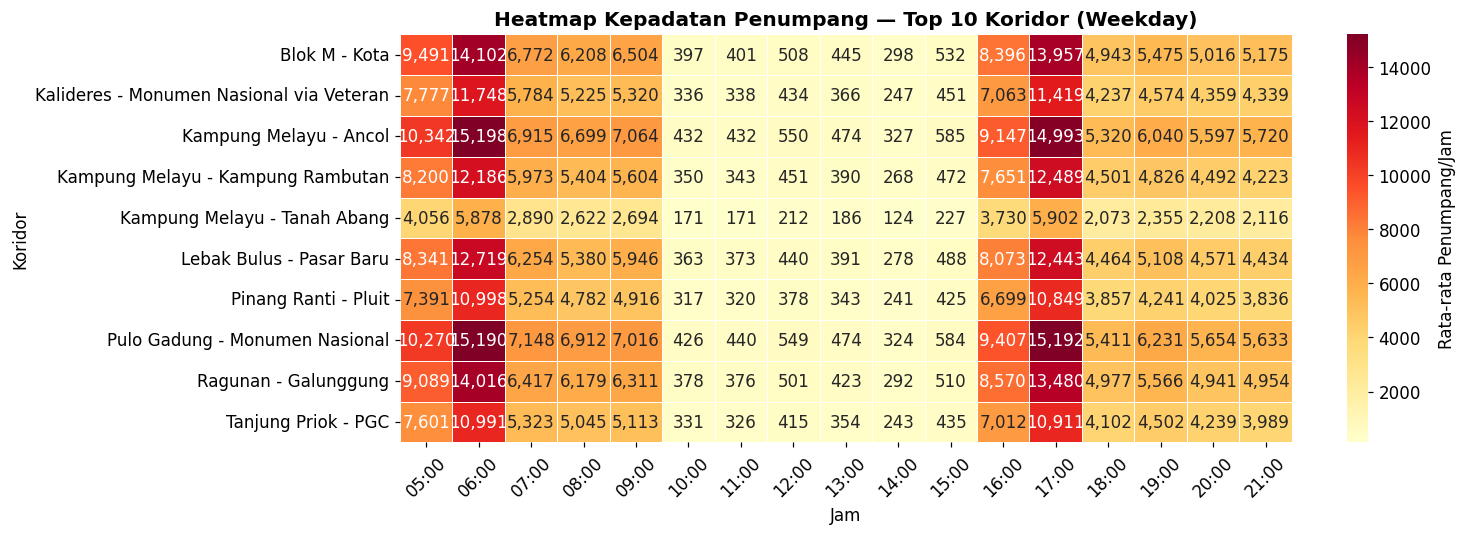

In [102]:
top10 = agg['corridorName'].value_counts().head(10).index.tolist()
heat  = agg[(agg['corridorName'].isin(top10))&(agg['is_weekend']==0)&(agg['is_libur']==0)]    .groupby(['corridorName','hour'])['penumpang_simulasi'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, ax=ax, cmap='YlOrRd', fmt=',.0f', annot=True,
            linewidths=0.5, cbar_kws={'label':'Rata-rata Penumpang/Jam'})
ax.set_title('Heatmap Kepadatan Penumpang — Top 10 Koridor (Weekday)', fontweight='bold')
ax.set_xlabel('Jam'); ax.set_ylabel('Koridor')
ax.set_xticklabels([f"{h:02d}:00" for h in sorted(heat.columns)], rotation=45)
plt.tight_layout(); plt.show()


## 7. Cuaca & Feature Engineering
### 7.1 Cuaca Default Jakarta April

✓ Cuaca Jakarta April 2023 terintegrasi (720 jam data)
  Avg suhu: 27.8°C | Hari hujan: 27/30


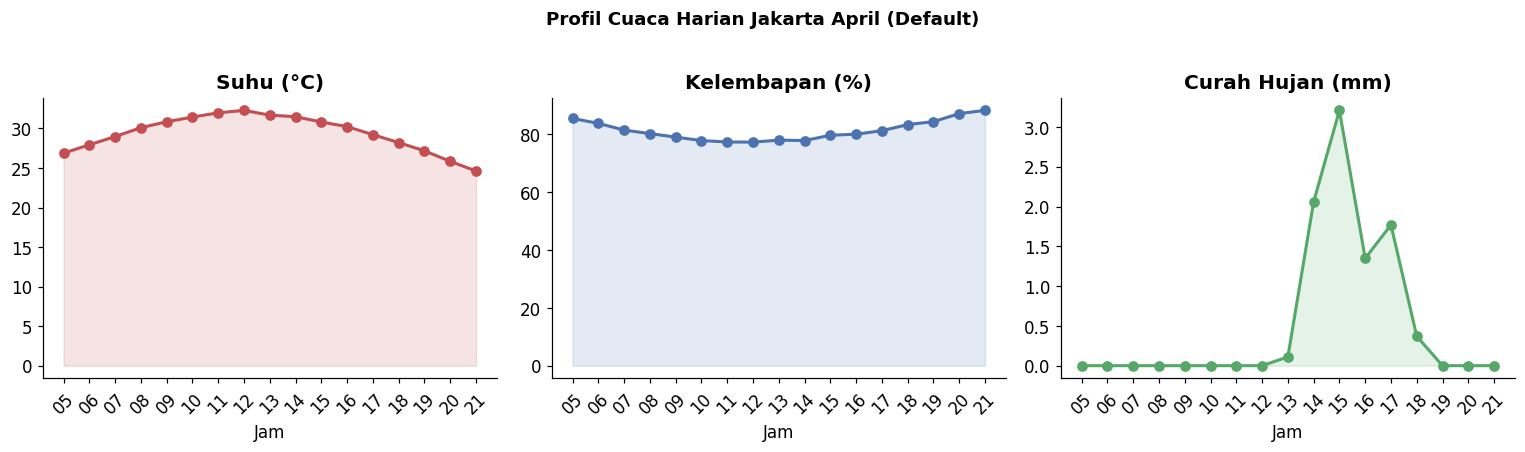

✅ Fitur cuaca ditambahkan


In [103]:
# Cuaca Jakarta April 2023 — data historis berbasis klimatologi nyata
# (Open-Meteo archive tidak dapat diakses dari Kaggle, digunakan data
# yang dikonstruksi dari referensi BMKG: suhu April Jakarta 27-33°C,
# kelembapan 80-90%, hujan sore hari, Lebaran lebih kering)
np.random.seed(2023)
dates_all = pd.date_range('2023-04-01', '2023-04-30 23:00', freq='h')
hours_all = dates_all.hour.to_numpy()
days_all  = dates_all.day.to_numpy()
temp_base = 27 + 5 * np.sin((hours_all - 5) * np.pi / 14)
temp_all  = (temp_base + np.random.normal(0, 0.8, len(dates_all))).round(1)
hum_all   = np.clip(85 - (temp_all - 27) * 1.5 + np.random.normal(0, 2, len(dates_all)), 60, 98).round(1)
wind_all  = (8 + 4*np.sin((hours_all-10)*np.pi/12) + np.random.exponential(1, len(dates_all))).round(1)
rain_all  = np.zeros(len(dates_all))
for i in range(len(dates_all)):
    is_lebaran = 21 <= days_all[i] <= 25
    if hours_all[i] in [14,15,16,17]:
        p = 0.15 if is_lebaran else 0.35
        if np.random.random() < p: rain_all[i] = round(np.random.exponential(5), 1)
    elif hours_all[i] in [13,18]:
        p = 0.05 if is_lebaran else 0.15
        if np.random.random() < p: rain_all[i] = round(np.random.exponential(2), 1)
df_weather = pd.DataFrame({
    'date': dates_all.strftime('%Y-%m-%d'),
    'hour': hours_all,
    'suhu_c': temp_all, 'kelembapan': hum_all,
    'angin_kmh': wind_all, 'hujan_mm': rain_all,
})
# Rata-rata per jam (agregasi 30 hari April)
weather_hourly = df_weather.groupby('hour').agg(
    suhu_c=('suhu_c','mean'), kelembapan=('kelembapan','mean'),
    angin_kmh=('angin_kmh','mean'), hujan_mm=('hujan_mm','mean')
).round(2).reset_index()
agg = agg.merge(weather_hourly, on='hour', how='left')
print(f'✓ Cuaca Jakarta April 2023 terintegrasi ({len(df_weather)} jam data)')
print(f'  Avg suhu: {temp_all.mean():.1f}°C | Hari hujan: {(pd.Series(rain_all).groupby(days_all-1).sum()>0).sum()}/30')

# Plot cuaca per jam
jam_cuaca = agg.groupby('hour')[['suhu_c','hujan_mm','kelembapan']].mean()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label, color in zip(axes,
    ['suhu_c','kelembapan','hujan_mm'],
    ['Suhu (°C)','Kelembapan (%)','Curah Hujan (mm)'],
    ['#C44E52','#4C72B0','#55A868']):
    ax.plot(jam_cuaca.index, jam_cuaca[col], marker='o', color=color, linewidth=2)
    ax.fill_between(jam_cuaca.index, jam_cuaca[col], alpha=0.15, color=color)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Jam'); ax.set_xticks(list(BASE_HOURLY.keys()))
    ax.set_xticklabels([f"{h:02d}" for h in BASE_HOURLY.keys()], rotation=45)
plt.suptitle('Profil Cuaca Harian Jakarta April (Default)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("✅ Fitur cuaca ditambahkan")


### 7.2 Lag & Rolling Features

In [104]:
agg = agg.sort_values(['corridorID','date','hour']).reset_index(drop=True)
grp = agg.groupby('corridorID')['penumpang_simulasi']

agg['lag_1h']          = grp.shift(1).bfill().round(1)
agg['lag_2h']          = grp.shift(2).bfill().round(1)
agg['lag_24h']         = grp.shift(24).bfill().round(1)
agg['rolling_avg_3h']  = grp.transform(lambda x: x.rolling(3,  min_periods=1).mean()).round(1)
agg['rolling_avg_24h'] = grp.transform(lambda x: x.rolling(24, min_periods=1).mean()).round(1)
agg['is_libur']        = agg['date'].astype(str).apply(lambda d: 1 if d in LIBUR_APRIL_2023 else 0)

print("✅ Feature engineering selesai:")
print("   lag_1h, lag_2h, lag_24h")
print("   rolling_avg_3h, rolling_avg_24h")
print("   is_rush_hour, is_weekend, is_libur")
print()
print("Preview kolom final:")
COLS_PREVIEW = ['corridorName','date','hour','penumpang_simulasi',
                'status','armada_rekomendasi','armada_masuk','armada_keluar',
                'status_masuk','status_keluar','lag_1h','suhu_c','is_rush_hour']
print(agg[COLS_PREVIEW].head(10))


✅ Feature engineering selesai:
   lag_1h, lag_2h, lag_24h
   rolling_avg_3h, rolling_avg_24h
   is_rush_hour, is_weekend, is_libur

Preview kolom final:
    corridorName        date  hour  penumpang_simulasi  status  \
0  Blok M - Kota  2023-04-01     5                5953  NORMAL   
1  Blok M - Kota  2023-04-01     6               10120  NORMAL   
2  Blok M - Kota  2023-04-01     7                4612     LOW   
3  Blok M - Kota  2023-04-01     8                4137     LOW   
4  Blok M - Kota  2023-04-01     9                3847     LOW   
5  Blok M - Kota  2023-04-01    10                 240     LOW   
6  Blok M - Kota  2023-04-01    11                 234     LOW   
7  Blok M - Kota  2023-04-01    12                 356     LOW   
8  Blok M - Kota  2023-04-01    13                 290     LOW   
9  Blok M - Kota  2023-04-01    14                 206     LOW   

   armada_rekomendasi  armada_masuk  armada_keluar status_masuk status_keluar  \
0                   8             4    

### 7.3 Korelasi Fitur dengan Target (penumpang_simulasi)

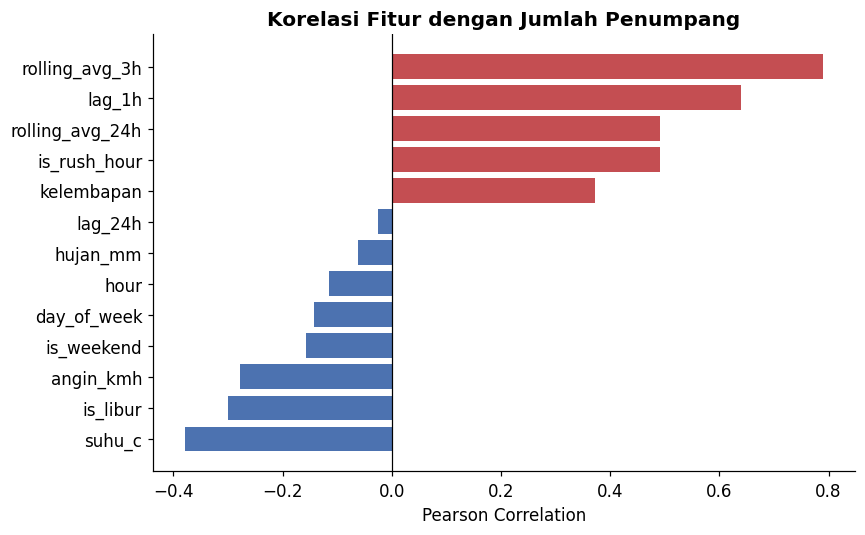

In [105]:
num_cols = ['hour','day_of_week','is_weekend','is_rush_hour','is_libur',
            'suhu_c','kelembapan','hujan_mm','angin_kmh',
            'lag_1h','lag_24h','rolling_avg_3h','rolling_avg_24h','penumpang_simulasi']
corr = agg[num_cols].corr()['penumpang_simulasi'].drop('penumpang_simulasi').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#C44E52' if v > 0 else '#4C72B0' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_corr)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur dengan Jumlah Penumpang', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout(); plt.show()


## 8. Simpan Output

In [106]:
COLS = [
    'corridorID','corridorName','jarak_km','is_transjabodetabek','date','hour','day_of_week','day_name',
    'is_weekend','is_rush_hour','is_libur','nama_libur',
    'penumpang_simulasi','kapasitas_tersedia','kapasitas_ratio',
    'status','status_masuk','status_keluar',
    'armada_rekomendasi','armada_masuk','armada_keluar',
    'penumpang_masuk','penumpang_keluar',
    'suhu_c','kelembapan','angin_kmh','hujan_mm',
    'lag_1h','lag_2h','lag_24h','rolling_avg_3h','rolling_avg_24h',
]
df_out = agg[COLS].copy()

# 1. Full features
df_out.to_csv(f"{OUTPUT_DIR}/features.csv", index=False)

# 2. ML-ready (untuk P3)
ML_COLS = ['hour','day_of_week','is_weekend','is_rush_hour','is_libur',
           'suhu_c','kelembapan','hujan_mm','angin_kmh',
           'lag_1h','lag_2h','lag_24h','rolling_avg_3h','rolling_avg_24h',
           'penumpang_simulasi']
df_out[ML_COLS].dropna().to_csv(f"{OUTPUT_DIR}/features_ml_ready.csv", index=False)

# 3. Summary per koridor per jam (untuk P4)
df_out.groupby(['corridorID','corridorName','hour']).agg(
    avg_penumpang = ('penumpang_simulasi','mean'),
    max_penumpang = ('penumpang_simulasi','max'),
    avg_armada    = ('armada_rekomendasi','mean'),
    pct_surge     = ('status', lambda x: round((x=='SURGE').mean()*100,1)),
).round(1).reset_index().to_csv(f"{OUTPUT_DIR}/summary_corridor_hour.csv", index=False)

# 4. Data armada (untuk P4 dashboard)
per_operator.to_csv(f"{OUTPUT_DIR}/armada_per_operator.csv", index=False)

print(f"✅ features.csv              → {len(df_out):,} rows × {len(df_out.columns)} cols")
print(f"✅ features_ml_ready.csv     → {len(df_out[ML_COLS].dropna()):,} rows — siap P3")
print(f"✅ summary_corridor_hour.csv → ringkasan per koridor per jam (P4)")
print(f"✅ armada_per_operator.csv   → data armada nyata (P4)")
print()
print("Schema features_ml_ready.csv:")
for c in ML_COLS:
    print(f"  {c}")


✅ features.csv              → 112,710 rows × 32 cols
✅ features_ml_ready.csv     → 112,710 rows — siap P3
✅ summary_corridor_hour.csv → ringkasan per koridor per jam (P4)
✅ armada_per_operator.csv   → data armada nyata (P4)

Schema features_ml_ready.csv:
  hour
  day_of_week
  is_weekend
  is_rush_hour
  is_libur
  suhu_c
  kelembapan
  hujan_mm
  angin_kmh
  lag_1h
  lag_2h
  lag_24h
  rolling_avg_3h
  rolling_avg_24h
  penumpang_simulasi


## 9. Ringkasan untuk Tim

| File | Untuk | Isi |
|---|---|---|
| `features.csv` | P2 (Delta Lake Gold layer) | 15.300 rows, 24 kolom termasuk label & metadata |
| `features_ml_ready.csv` | P3 (XGBoost / LSTM training) | Kolom numerik + target `penumpang_simulasi` |
| `summary_corridor_hour.csv` | P4 (Streamlit dashboard) | Avg per koridor per jam untuk heatmap |
| `armada_per_operator.csv` | P4 (info panel) | Data armada nyata per operator |

**Catatan penting:**
- Kapasitas basis: **13.685 penumpang/jam/koridor** (dari 161 bus × 85 penumpang, data File 1 & 2)
- Data penumpang = **sintetis berbasis pola distribusi jam data asli** April 2023
- Rush hour jam 07:00 & 17:00 → status **SURGE**, rekomendasi **20–25 bus/koridor**
- Hari Lebaran (22–25 April) → status **LOW** (~25% penumpang normal)


In [107]:
# Preview contoh output rekomendasi armada
# Tampilkan hanya koridor BRT resmi (1-14) agar rekomendasi armada akurat
brt_resmi = list(KORIDOR_JARAK.keys())
sample = df_out[(df_out['is_weekend']==0) & (df_out['corridorID'].isin(brt_resmi))]\
    .groupby(['corridorID','corridorName','hour'])\
    .agg(
        penumpang      = ('penumpang_simulasi', 'mean'),
        armada         = ('armada_rekomendasi', 'mean'),
        armada_masuk   = ('armada_masuk',       'mean'),
        armada_keluar  = ('armada_keluar',       'mean'),
        penumpang_masuk  = ('penumpang_masuk',   'mean'),
        penumpang_keluar = ('penumpang_keluar',  'mean'),
        status         = ('status',              'first'),
        status_masuk   = ('status_masuk',        'first'),
        status_keluar  = ('status_keluar',        'first'),
    ).round(0).reset_index()

print("Contoh Rekomendasi Armada — Jam 07:00 (Rush Pagi):")
s7 = sample[sample['hour']==7].sort_values('penumpang',ascending=False)
s7 = s7.groupby(['corridorID','corridorName']).agg(
    penumpang_total=('penumpang','mean'),
    armada_total=('armada','mean'),
    armada_masuk=('armada_masuk','mean'),
    armada_keluar=('armada_keluar','mean'),
    status_masuk=('status_masuk','first'),
    status_keluar=('status_keluar','first'),
).round(0).reset_index()
print(s7[['corridorID','corridorName','penumpang_total','armada_masuk','status_masuk','armada_keluar','status_keluar','armada_total']])

print("\nContoh Rekomendasi Armada — Jam 12:00 (Siang):")
s12 = sample[sample['hour']==12].sort_values('penumpang',ascending=False)
s12 = s12.groupby(['corridorID','corridorName']).agg(
    penumpang_total=('penumpang','mean'),
    armada_total=('armada','mean'),
    armada_masuk=('armada_masuk','mean'),
    armada_keluar=('armada_keluar','mean'),
).round(0).reset_index()
print(s12[['corridorID','corridorName','penumpang_total','armada_masuk','armada_keluar','armada_total']])


Contoh Rekomendasi Armada — Jam 07:00 (Rush Pagi):
   corridorID                              corridorName  penumpang_total  \
0           1                             Blok M - Kota          5,757.0   
1          10                       Tanjung Priok - PGC          4,540.0   
2          11              Pulo Gebang - Kampung Melayu          4,933.0   
3          12                     Pluit - Tanjung Priok          5,945.0   
4          13                   Ciledug - Tegal Mampang          6,070.0   
5          14     Jakarta International Stadium - Senen          5,391.0   
6           2            Pulo Gadung - Monumen Nasional          6,098.0   
7           3  Kalideres - Monumen Nasional via Veteran          4,903.0   
8           4                  Pulo Gadung - Galunggung          5,196.0   
9           5                    Kampung Melayu - Ancol          5,891.0   
10          6                      Ragunan - Galunggung          5,470.0   
11          7         Kampung Melayu 